# GSE44076: First Expression Plots

This notebook makes a first exploratory pass over the GSE44076 expression matrix. It verifies sample alignment, inspects the observed value scale, and creates simple distribution plots.

The scope is descriptive only. No PCA, clustering, differential expression, gene ranking, biomarker selection, or biological inference is performed.

## Setup

Raw and processed tables remain local. Generated figures are written to `reports/figures/` for version control.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.geo_loader import (  # noqa: E402
    align_expression_with_metadata,
    build_sample_metadata_table,
    convert_expression_to_numeric,
    load_geo_expression_table,
    read_geo_series_lines,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE44076_series_matrix.txt.gz"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "sample_metadata.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GROUP_MAP = {
    "Healthy colon mucosa cells": "healthy_mucosa",
    "Normal distant colon mucosa cells": "paired_normal_mucosa",
    "Primary colon adenocarcinoma cells": "tumor",
}
GROUP_ORDER = ["healthy_mucosa", "paired_normal_mucosa", "tumor"]
GROUP_COLORS = ["#2A9D8F", "#E9C46A", "#C8553D"]

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Load Expression and Metadata

The local processed metadata table is used when available. Otherwise, it is rebuilt from the same GEO series matrix metadata.

In [2]:
if not RAW_PATH.is_file():
    raise FileNotFoundError(
        "GSE44076 series matrix not found. Place the downloaded file at "
        f"{RAW_PATH}"
    )

expression = load_geo_expression_table(RAW_PATH)

if METADATA_PATH.is_file():
    sample_metadata = pd.read_csv(METADATA_PATH)
    metadata_source = METADATA_PATH.relative_to(PROJECT_ROOT)
else:
    sample_metadata = build_sample_metadata_table(read_geo_series_lines(RAW_PATH))
    sample_metadata["group"] = sample_metadata["source_name"].map(GROUP_MAP)
    metadata_source = RAW_PATH.relative_to(PROJECT_ROOT)

if "group" not in sample_metadata:
    sample_metadata["group"] = sample_metadata["source_name"].map(GROUP_MAP)
if sample_metadata["group"].isna().any():
    raise ValueError("Some sample source names do not have a documented group label.")

print(f"Expression table before alignment: {expression.shape}")
print(f"Metadata table: {sample_metadata.shape}")
print(f"Metadata source: {metadata_source}")

Expression table before alignment: (49386, 247)
Metadata table: (246, 10)
Metadata source: data\processed\sample_metadata.csv


## Align Samples and Convert Values

Expression columns are reordered to match metadata rows. The probe identifier is retained while sample values are converted to numeric form.

In [3]:
expression, sample_metadata = align_expression_with_metadata(expression, sample_metadata)
expression = convert_expression_to_numeric(expression)

sample_columns = sample_metadata["sample_accession"].tolist()
expression_values = expression[sample_columns]

print(f"Aligned expression table: {expression.shape}")
print(f"Numeric expression matrix: {expression_values.shape}")
print(f"Missing numeric values: {int(expression_values.isna().sum().sum()):,}")
assert sample_columns == expression.columns[1:].tolist()

Aligned expression table: (49386, 247)
Numeric expression matrix: (49386, 246)
Missing numeric values: 0


## Observed Expression Range

These summaries describe the values as provided in the series matrix. They do not by themselves establish which normalization or transformation steps were applied upstream.

In [4]:
value_summary = expression_values.stack().describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
)
display(value_summary.to_frame("expression_value"))

sample_summary = pd.DataFrame(
    {
        "minimum": expression_values.min(),
        "median": expression_values.median(),
        "maximum": expression_values.max(),
    }
).join(sample_metadata.set_index("sample_accession")[["group"]])
display(sample_summary.head())

,expression_value
count,1.214896e+07
mean,4.585736e+00
std,2.413693e+00
min,1.416100e+00
1%,1.896900e+00
25%,2.541800e+00
50%,3.702500e+00
75%,6.319500e+00
99%,1.122410e+01
max,1.399370e+01


,minimum,median,maximum,group
GSM1077598,1.5614,3.66720,13.7893,healthy_mucosa
GSM1077599,1.5568,3.65155,13.8643,healthy_mucosa
GSM1077600,1.5208,3.72390,13.8643,healthy_mucosa
GSM1077601,1.6243,3.69330,13.8707,healthy_mucosa
GSM1077602,1.5744,3.65625,13.8662,healthy_mucosa


## Sample Expression Distributions

A regularly spaced subset of 24 samples keeps the boxplot legible while showing distributions across the matrix order.

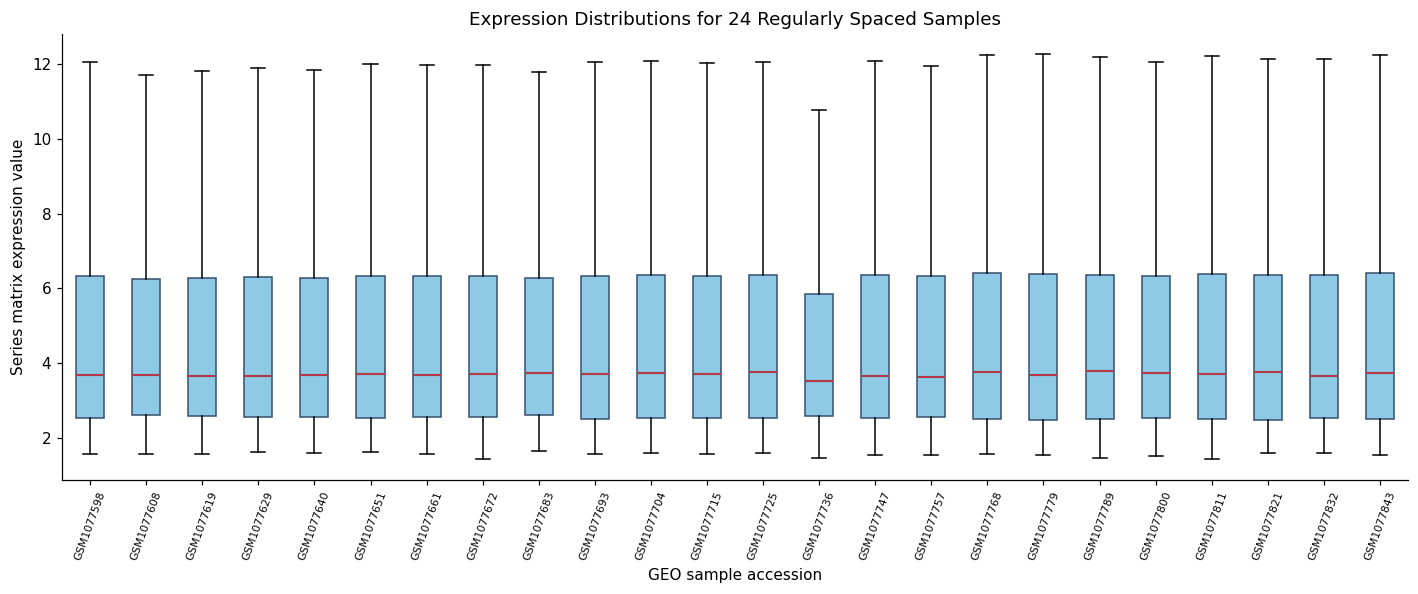

In [5]:
subset_indices = np.linspace(0, len(sample_columns) - 1, 24, dtype=int)
subset_samples = [sample_columns[index] for index in subset_indices]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.boxplot(
    [expression_values[column].dropna() for column in subset_samples],
    tick_labels=subset_samples,
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#8ECAE6", "edgecolor": "#355070"},
    medianprops={"color": "#B23A48", "linewidth": 1.4},
)
ax.set_title("Expression Distributions for 24 Regularly Spaced Samples")
ax.set_xlabel("GEO sample accession")
ax.set_ylabel("Series matrix expression value")
ax.tick_params(axis="x", rotation=70, labelsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_expression_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()

## Overall Value Distribution

Every twentieth probe row is sampled deterministically for a compact view of the overall expression-value distribution.

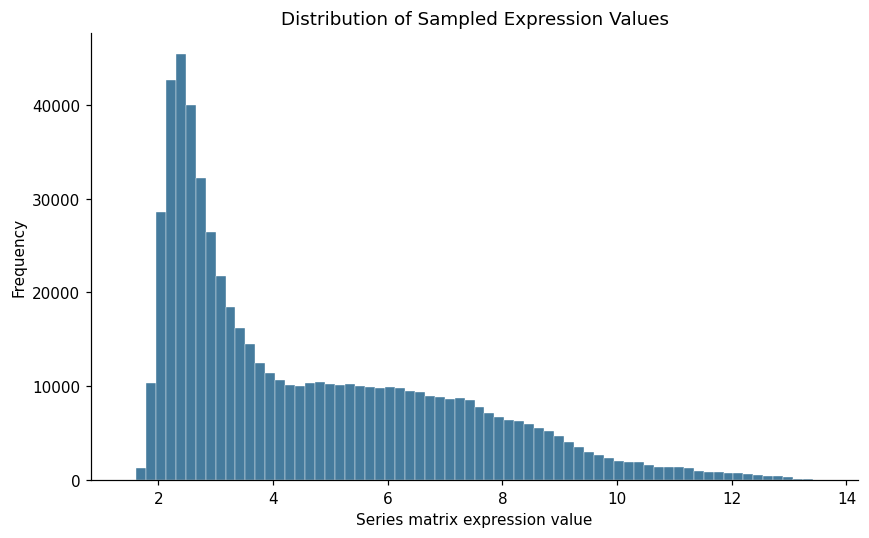

In [6]:
plot_values = expression_values.iloc[::20].to_numpy().ravel()
plot_values = plot_values[~np.isnan(plot_values)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(plot_values, bins=70, color="#457B9D", edgecolor="white", linewidth=0.25)
ax.set_title("Distribution of Sampled Expression Values")
ax.set_xlabel("Series matrix expression value")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "expression_value_histogram.png", dpi=180, bbox_inches="tight")
plt.show()

## Per-Sample Median Distribution

Per-sample medians provide a simple check for broad location shifts. Group colors are descriptive metadata labels, not evidence of biological separation.

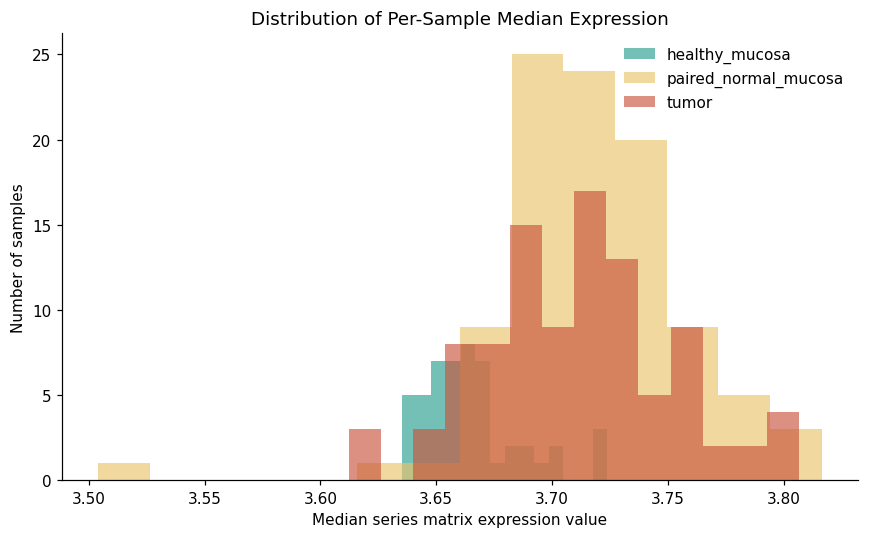

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for group, color in zip(GROUP_ORDER, GROUP_COLORS, strict=True):
    group_medians = sample_summary.loc[sample_summary["group"] == group, "median"]
    ax.hist(group_medians, bins=14, alpha=0.65, label=group, color=color)

ax.set_title("Distribution of Per-Sample Median Expression")
ax.set_xlabel("Median series matrix expression value")
ax.set_ylabel("Number of samples")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_median_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## Sample Counts by Group

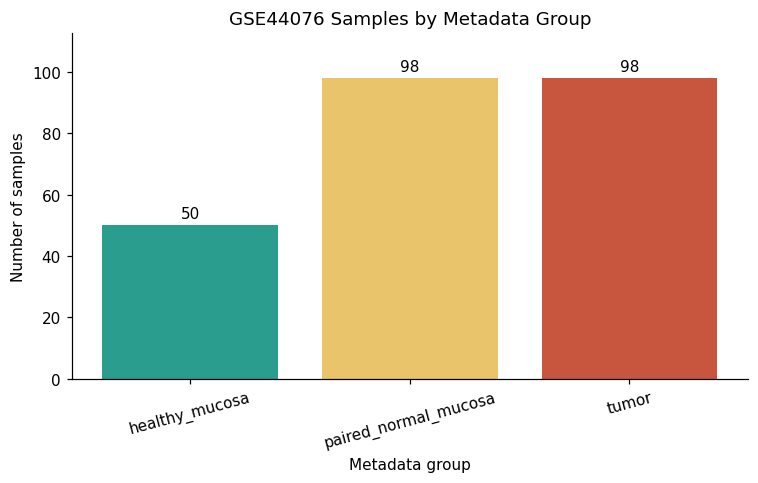

,sample_count
group,
healthy_mucosa,50
paired_normal_mucosa,98
tumor,98


In [8]:
group_counts = sample_metadata["group"].value_counts().reindex(GROUP_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(group_counts.index, group_counts.values, color=GROUP_COLORS)
ax.bar_label(bars, padding=3)
ax.set_title("GSE44076 Samples by Metadata Group")
ax.set_xlabel("Metadata group")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=15)
ax.set_ylim(0, group_counts.max() * 1.15)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_group_counts.png", dpi=180, bbox_inches="tight")
plt.show()

display(group_counts.rename("sample_count").to_frame())

## Checks Needed Before Deeper Analysis

- Confirm the platform annotation and the mapping from probe identifiers to genes.
- Verify the preprocessing and normalization history documented by GEO and the original study.
- Examine sample-level quality-control information and possible technical covariates.
- Preserve the paired design linking normal mucosa and tumor samples from the same individuals.
- Define any later statistical question and analysis plan before testing group differences.